## 5.1 Evaluating generative text models

### 5.1.1 Using GPT to generate text

In [ ]:
import os
import urllib.request

if not os.path.exists("chapter04.py"):
    url = "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/refs/heads/main/ch05/01_main-chapter-code/previous_chapters.py"
    file_path = "chapter04.py"
    urllib.request.urlretrieve(url, file_path)
    print("Fiel Downloaded")

Fiel Downloaded


In [5]:
# 使用 colab 需要每次上传 chapter04.py 到colab服务器。修改服务器中文件后需要重启python kernel才能读取更新后的文件
import torch
from chapter04 import GPTModel

In [ ]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "context_length": 256,      # context_length 改为256，以便在笔记本上进行训练
    "emb_dim": 768,
    "n_heads": 12,
    "n_layers": 12,
    "drop_rate": 0.1,
    "qkv_bias": False
}
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.eval() # 推理/预测不需要随机性，只有训练时需要

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

```torch.unsqueeze(input, dim) → Tensor```

返回一个在指定位置插入了一个维度大小为1的新张量。    
返回的张量与这个张量共享相同的基本数据。

```
>>> x = torch.tensor([1, 2, 3, 4])
>>> torch.unsqueeze(x, 0)
tensor([[ 1,  2,  3,  4]])
>>> torch.unsqueeze(x, 1)
tensor([[ 1],
        [ 2],
        [ 3],
        [ 4]])
```
一句话理解

* `squeeze` → 删掉值为 1 的维度    
* `unsqueeze` → 在指定位置插入一个值为 1 的维度

```python
x = torch.rand(3, 4)   # [3, 4]

x.unsqueeze(0)   # [1, 3, 4]  → 在最前面插入
x.unsqueeze(1)   # [3, 1, 4]  → 在中间插入
x.unsqueeze(2)   # [3, 4, 1]  → 在最后面插入
x.unsqueeze(-1)  # [3, 4, 1]  → 负数从后数，-1就是最后
```

```python
x = torch.rand(1, 3, 1, 4)   # [1, 3, 1, 4]

x.squeeze()    # [3, 4]      → 删掉所有 size=1 的维度
x.squeeze(0)   # [3, 1, 4]   → 只删 dim=0（它是1，所以成功）
x.squeeze(1)   # [1, 3, 1, 4] → dim=1 的 size 是 3，不是1，什么都不做
x.squeeze(2)   # [1, 3, 4]   → 只删 dim=2
```

在深度学习中：   
**输入 = batch**

所以必须是：   
**(batch, sequence)**

维度变化： 一维tensor `(seq_len,)` 执行 `.unsqueeze(0)` 后变成 `(1, seq_len)`

In [ ]:
# unsqueeze 作用是解序列，把数据变成更高一维的数据，原数据作为新数据的列或者行
test = torch.tensor([[1, 2, 3], [4, 5, 6]])
print(test.shape)
unsqu_test = test.unsqueeze(0)
print(unsqu_test, unsqu_test.shape)

print()
test = torch.tensor([[1 ,2, 3, 4, 5, 6]])
print(test.shape)
squ_test = test.squeeze(0)
print(squ_test, squ_test.shape)

a = torch.tensor([[ 6109,  3626,  6100,   345, 34245,  5139,  2492, 25405, 17434, 17853,
          5308,  3398, 13174, 43071]]).squeeze(0)
print(a)
print(tokenizer.decode(a.tolist()))

torch.Size([2, 3])
tensor([[[1, 2, 3],
         [4, 5, 6]]]) torch.Size([1, 2, 3])

torch.Size([1, 6])
tensor([1, 2, 3, 4, 5, 6]) torch.Size([6])


![text to token ids and token ids to text](https://raw.githubusercontent.com/ipdor/Pictures/master/20260430172326536.png)

In [ ]:
import tiktoken
from chapter04 import generate_text_simple

# 把 text 用分词器转换为token ids，返回batch化后的tensor
def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'}) # list[int]
    # print(torch.tensor(encoded).shape) # [4]
    encoded_tensor = torch.tensor(encoded).unsqueeze(0) # 1D (seq_len,) -> 2D (1, seq_len)， batch size =1
    # print(encoded_tensor.shape) # [1, 4]
    return encoded_tensor

# token ids转换为文本后序列化并返回
def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0)
    return tokenizer.decode(flat.tolist())

start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model = model,
    idx = text_to_token_ids(start_context, tokenizer),
    max_new_tokens = 10,
    context_size = GPT_CONFIG_124M["context_length"]
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you rentingetic wasnم refres RexMeCHicular stren


### 5.1.2 Calculating the text generation loss

![from input text to output text](https://raw.githubusercontent.com/ipdor/Pictures/master/20260425144904485.png)

用两个输入示例（"every effort moves" 和 "I really like"）来演示输入到输出文本的大概过程

In [9]:
inputs = torch.tensor([[16833, 3626, 6100],     # ["every effort moves",
                       [40, 1107, 588]])        # "I really like"]

目标是生成下面的两组target数据，注意 target 是inputs向后移动一个字符的内容

In [10]:
targets = torch.tensor([[3626, 6100, 345 ],     # [" effort moves you",
                        [1107, 588, 11311]])    # " really like chocolate"]

In [11]:
with torch.no_grad():
    logits = model(inputs)
probas = torch.softmax(logits, dim=-1)          # 对应图5.4, step 2 将logits转换为概率probability scores
print(probas.shape) # [batch_size, num_tokens, embedding_dim] = [2, 3, 50257]

torch.Size([2, 3, 50257])


In [12]:
# 对应图5.4, step 3 and 4 对概率调用argmax获取预测的的token ids
token_ids = torch.argmax(probas, dim=-1, keepdim=True) 
print("Token IDs:\n", token_ids)

Token IDs:
 tensor([[[16657],
         [  339],
         [42826]],

        [[49906],
         [29669],
         [41751]]])


In [13]:
# 对应图5.4, step 5 将 index 映射回文本text
print(f"Targets batch 1: {token_ids_to_text(targets[0], tokenizer)}")
print(f"Outputs batch 1:"
f" {token_ids_to_text(token_ids[0].flatten(), tokenizer)}")

Targets batch 1:  effort moves you
Outputs batch 1:  Armed heNetflix


#### 手工实现计算交叉熵损失，实现模型评估

评估过程：   
1. 通过比较生成的文本和目标文本，用定量的方式确定生成token的质量，表示它们之间的"距离"；   
2. 后期使用的训练函数将会使用这种"距离"来更新模型权重，实现优化的目的。

![Calculating the loss ](https://raw.githubusercontent.com/ipdor/Pictures/master/20260425171205961.png)


In [14]:
test = torch.tensor([[1, 2, 3], 
                    [4, 5, 6], 
                    [7, 8, 9]])
sliced = test[[0,1,2], [0,1,2]] # 按顺序组合，取test(0, 0), (1, 1), (2, 2)
print(sliced)

tensor([1, 5, 9])


In [15]:
# probas [batch_size, num_tokens, embedding_dim] = [2, 3, 50257]
# target [batch_size, num_tokens] = [2, 3]
text_idx = 0
print(targets[text_idx])  # 
target_probas_1 = probas[text_idx, [0,1,2]]
print("Text 1:", target_probas_1)   # 取 probas[0, [0,1,2]]， 因为刚好只有3行，也就是第一批里面所有内容，等价 probas[0]

# 切片第二维 [0,1,2]                                        三个 token 的位置索引
# 切片第三维 targets[text_idx] = ([3626, 6100,  345])       三个位置的正确 token ID !
# 搭配第0维 text_idx=0                                      第一批token
# 组合起来就是 [0, 0, 3626] [0, 1, 6100]  [0, 2, 345] 取probas[0] 第0行的3626列，第一行的6100列，第三行的345列
# 分别是输出第一批中，正确的第一个字符、第二个字符、第三个字符对应的概率
print(probas[text_idx, 0, 3626], probas[text_idx, 1, 6100], probas[text_idx, 2, 345])
print(probas[text_idx, [0,1,2], targets[text_idx]])

tensor([3626, 6100,  345])
Text 1: tensor([[1.8849e-05, 1.5172e-05, 1.1687e-05,  ..., 2.2409e-05, 6.9776e-06,
         1.8776e-05],
        [9.1569e-06, 1.0062e-05, 7.8786e-06,  ..., 2.9090e-05, 6.0103e-06,
         1.3571e-05],
        [2.9877e-05, 8.8507e-06, 1.5741e-05,  ..., 3.5456e-05, 1.4094e-05,
         1.3526e-05]])
tensor(7.4540e-05) tensor(3.1061e-05) tensor(1.1563e-05)
tensor([7.4540e-05, 3.1061e-05, 1.1563e-05])


图 5.7 第一到三步：

In [16]:
# 打印训练前和目标标记相对应的初始 softmax 概率分数（从模型输出的概率分布中，取出“正确 token 的概率”)
# [0,1,2]               三个 token 的位置索引
# targets[text_idx]     三个位置的正确 token ID !
text_idx = 0
target_probas_1 = probas[text_idx, [0,1,2], targets[text_idx]]
print("Text 1:", target_probas_1)

text_idx = 1
target_probas_2 = probas[text_idx, [0,1,2], targets[text_idx]]
print("Text 2:", target_probas_2)

Text 1: tensor([7.4540e-05, 3.1061e-05, 1.1563e-05])
Text 2: tensor([1.0337e-05, 5.6776e-05, 4.7559e-06])


图 5.7 第四步：

In [17]:
log_probas = torch.log(torch.cat((target_probas_1, target_probas_2)))
print(log_probas)

tensor([ -9.5042, -10.3796, -11.3677, -11.4798,  -9.7764, -12.2561])


In [18]:
avg_log_probas = torch.mean(log_probas)
print(avg_log_probas)

tensor(-10.7940)


交叉熵损失 (***cross entropy* loss**) : 把平均对数概率average log probability变为负的平均对数概率negative average log probability的操作。

核心上，交叉熵损失是机器学习和深度学习中一种流行的度量方法，用于衡量两个概率分布之间的差异——通常是标签的真实分布（在这里，是数据集中的标记）和来自模型的预测分布（例如，LLM 生成的标记概率）。

In [19]:
neg_avg_log_probas = avg_log_probas * -1
print(neg_avg_log_probas)

tensor(10.7940)


#### 调用框架实现计算交叉熵损失

In [20]:
print("Logits shape:", logits.shape)
print("Targets shape:", targets.shape)

Logits shape: torch.Size([2, 3, 50257])
Targets shape: torch.Size([2, 3])


In [21]:
logits_flat = logits.flatten(0, 1)
targets_flat = targets.flatten()
print("Flattened logits:", logits_flat.shape)
print("Flattened targets:", targets_flat.shape)

Flattened logits: torch.Size([6, 50257])
Flattened targets: torch.Size([6])


Pytorch 支持直接计算出负的平均对数概率negative average log probability，省去调用 `softmax` 计算概率、选择与target ID 相对应的概率分数、计算负平均对数概率这些步骤。


In [22]:
loss = torch.nn.functional.cross_entropy(logits_flat, targets_flat)
print(loss)

tensor(10.7940)


### 5.1.3 Calculating the training and validation set losses

书中附录A A.7 A typical training loop解释了使用验证集（Validation set）的两个主要原因：

1. **调整超参数**：我们在训练过程中会多次使用验证集来寻找最佳的模型设置（如学习率、训练轮数等），以此来优化模型，而不会污染最终只保留作一次性评估的测试集。    
2. **监控过拟合**：如果在训练时，训练集损失持续下降，但验证集损失却停滞或变大，这就直接说明模型只是在“死记硬背”训练数据（也就是过拟合）。


In [23]:
import os
import urllib.request


if not os.path.exists("the-verdict.txt"):
    url = "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/refs/heads/main/ch02/01_main-chapter-code/the-verdict.txt"
    file_path = "the-verdict.txt"
    urllib.request.urlretrieve(url, file_path)
    print("Fiel Downloaded")

Fiel Downloaded


In [24]:
file_path = "the-verdict.txt"
with open(file_path, "r", encoding="utf-8") as file:
    text_data = file.read()
print(text_data[:200])

I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no great surprise to me to hear that, in the height of his glory, he had dropped his painting, married a


In [25]:
total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))
print("Characters:", total_characters)
print("Tokens:", total_tokens)

Characters: 20479
Tokens: 5145


In [26]:
train_ratio = 0.9
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]
print("split_idx:", split_idx)

split_idx: 18431


In [27]:
from chapter04 import create_dataloader_v1
torch.manual_seed(123)

train_loader = create_dataloader_v1(
    train_data,
    batch_size = 2,
    max_length = GPT_CONFIG_124M["context_length"],
    stride = GPT_CONFIG_124M["context_length"],
    drop_last = True,
    shuffle = True,
    num_workers = 0
)

val_loader = create_dataloader_v1(
    val_data,
    batch_size = 2,
    max_length = GPT_CONFIG_124M["context_length"],
    stride = GPT_CONFIG_124M["context_length"],
    drop_last = False,
    shuffle = False,
    num_workers = 0
)

In [28]:
print("Train loader:")
for x, y in train_loader:
    print(x.shape, y.shape)

print("\nValidation loader:")
for x, y in val_loader:
    print(x.shape, y.shape)

Train loader:
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])

Validation loader:
torch.Size([2, 256]) torch.Size([2, 256])


```torch.flatten(input, start_dim=0, end_dim=-1) → Tensor```


将input重塑为一维张量。如果传递了start_dim或end_dim，则仅从start_dim开始到end_dim结束的维度被压平。元素在input中的顺序保持不变。

In [29]:
n = torch.rand(2,3,4) # [batch_size, seq_len, emb_dim]

print(n, n.shape)
# print(n.flatten()) # 直接调用是转换为1维[1,n]
print(n.flatten(0,1).shape)   # flatten 前2个维度，相当于每个batch连在第一个batch的下面 [6, 4]

# n.flatten(0,1)不等价于下面的stack，等价于下面的cat
print(torch.stack((n[0], n[1]), dim=0)) # 新增一个维度再拼接 2 × [3,4] -> [2, 3, 4]
print(torch.cat((n[0], n[1]), dim=0))   # 沿已有维度拼接 2 × [3,4] -> [6, 4]

tensor([[[0.1366, 0.1025, 0.1841, 0.7264],
         [0.3153, 0.6871, 0.0756, 0.1966],
         [0.3164, 0.4017, 0.1186, 0.8274]],

        [[0.3821, 0.6605, 0.8536, 0.5932],
         [0.6367, 0.9826, 0.2745, 0.6584],
         [0.2775, 0.8573, 0.8993, 0.0390]]]) torch.Size([2, 3, 4])
torch.Size([6, 4])
tensor([[[0.1366, 0.1025, 0.1841, 0.7264],
         [0.3153, 0.6871, 0.0756, 0.1966],
         [0.3164, 0.4017, 0.1186, 0.8274]],

        [[0.3821, 0.6605, 0.8536, 0.5932],
         [0.6367, 0.9826, 0.2745, 0.6584],
         [0.2775, 0.8573, 0.8993, 0.0390]]])
tensor([[0.1366, 0.1025, 0.1841, 0.7264],
        [0.3153, 0.6871, 0.0756, 0.1966],
        [0.3164, 0.4017, 0.1186, 0.8274],
        [0.3821, 0.6605, 0.8536, 0.5932],
        [0.6367, 0.9826, 0.2745, 0.6584],
        [0.2775, 0.8573, 0.8993, 0.0390]])


In [30]:
def calc_loss_batch(input_batch, output_batch, model, device):
    # [2, 256]
    input_batch = input_batch.to(device)
    output_batch = output_batch.to(device)
    # [2, 256, 50257]
    logits = model(input_batch)
    # [N=512, C=50257], [N=512] 要求除了C之外其他维度完全匹配
    loss = torch.nn.functional.cross_entropy(
        logits.flatten(0,1), output_batch.flatten()
    )
    return loss

In [31]:
# 测试 calc_loss_batch
input_b = torch.randint(0, 9, (2,256))
output_b = torch.randint(0, 9, (2,256))

calc_loss_batch(input_b, output_b, model, "cpu")

tensor(10.8606, grad_fn=<NllLossBackward0>)

In [32]:
# 遍历计算给定数据加载器中的所有批次的loss, 最后返回平均loss
def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0
    if len(data_loader)==0:
        return float("Nan")
    elif num_batches==None:
        num_batches = len(data_loader) # 如果未指定批数，使用所有数据
    else:
        # 如果 `num_batches` 超过了数据加载器中的批次数，则减少批次数以匹配实际所有的总批次数
        num_batches = min(len(data_loader), num_batches)
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i >= num_batches:
            break
        loss = calc_loss_batch(input_batch, target_batch, model, device)
        total_loss += loss.item()
    return total_loss / num_batches

In [33]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

with torch.no_grad(): # 尚未开始训练，为了提高效率，禁用梯度追踪
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)

print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 10.987583584255642
Validation loss: 10.98110580444336


## 5.2 Training an LLM

![Train loop](https://raw.githubusercontent.com/ipdor/Pictures/master/20260426172033736.png)

图 5.11 中的流程图描绘了一个典型的 PyTorch 神经网络训练工作流，我们将其用于训练 LLM。它概述了八个步骤，从迭代每个 epoch 开始，接着是处理批次、重置梯度、计算损失和新梯度、更新权重，最后以打印损失和生成文本样本等监控步骤结束。

In [34]:
def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs, eval_freq, eval_iter, start_context, tokenizer):
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    # 1) Iterate over training epochs
    for epoch in range(num_epochs):
        model.train()
        # 2) Iterate over batches ineach training epoch
        for input_batch, target_batch in train_loader:
            # 3) Reset loss gradients from previous batch iteration
            optimizer.zero_grad()
            # 4) Calculate loss on current batch
            loss = calc_loss_batch(
                input_batch, target_batch, model, device
            )
            # 5) Backward pass to calculate loss gradients
            loss.backward()
            # 6) Update model weightsusing loss gradients
            optimizer.step()
            tokens_seen += input_batch.numel()
            global_step+=1

            # 7) Print training and validation set losses
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter
                )
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Stpen {global_step:06d}): "
                    f"Train loss {train_loss:.3f}, "
                    f"Val loss {val_loss:.3f}"
                )
        # 8) Generate sample text for visual inspection
        # 每个epoch训练后打印样例
        generate_and_print_sample(model, tokenizer, device, start_context)
    return train_losses, val_losses, track_tokens_seen 

# 在每次模型update之后打印训练和验证集的loss，提供数值估计
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    # 为了稳定，可复现的结果，关闭Dropout
    model.eval()
    with torch.no_grad():   # 关闭梯度跟踪，评估时不需要，可以减小计算资源的使用
        train_loss = calc_loss_loader(
            train_loader, model, device, num_batches=eval_iter
        )
        val_loss = calc_loss_loader(
            val_loader, model, device, num_batches=eval_iter
        )
    model.train()
    return train_loss, val_loss

# 同样为了评估进度，提供具体的文本样例
def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
            model = model, idx = encoded, 
            max_new_tokens = 50, context_size=context_size
    )
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))
    model.train()

In [35]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.0004, weight_decay = 0.1
)
num_epochs = 10
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context="Every effort moves you", tokenizer=tokenizer
)

Ep 1 (Stpen 000000): Train loss 9.818, Val loss 9.930
Ep 1 (Stpen 000005): Train loss 8.066, Val loss 8.336
Every effort moves you,,,,,,,,,,,,.                                     
Ep 2 (Stpen 000010): Train loss 6.623, Val loss 7.053
Ep 2 (Stpen 000015): Train loss 6.047, Val loss 6.605
Every effort moves you, and,, and,,,,,,, and,.                                   
Ep 3 (Stpen 000020): Train loss 5.532, Val loss 6.507
Ep 3 (Stpen 000025): Train loss 5.399, Val loss 6.389
Every effort moves you, and to the to the of the to the, and I had. Gis, and, and, and, and, and, and I had the, and, and, and, and, and, and, and, and, and
Ep 4 (Stpen 000030): Train loss 4.895, Val loss 6.280
Ep 4 (Stpen 000035): Train loss 4.648, Val loss 6.304
Every effort moves you.  "I the picture.                    "I"I the picture"I had the the honour of the picture and I had been the picture of
Ep 5 (Stpen 000040): Train loss 4.023, Val loss 6.165
Every effort moves you know                                

```
Ep 1 (Stpen 000000): Train loss 9.781, Val loss 9.933
Ep 1 (Stpen 000005): Train loss 8.111, Val loss 8.339
Every effort moves you,,,,,,,,,,,,.                                     
Ep 2 (Stpen 000010): Train loss 6.661, Val loss 7.048
Ep 2 (Stpen 000015): Train loss 5.961, Val loss 6.616
Every effort moves you, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and,, and, and,
Ep 3 (Stpen 000020): Train loss 5.726, Val loss 6.600
Ep 3 (Stpen 000025): Train loss 5.201, Val loss 6.348
Every effort moves you, and I had been.                                            
Ep 4 (Stpen 000030): Train loss 4.417, Val loss 6.278
Ep 4 (Stpen 000035): Train loss 4.069, Val loss 6.226
Every effort moves you know the                          "I he had the donkey and I had the and I had the donkey and down the room, I had
Ep 5 (Stpen 000040): Train loss 3.732, Val loss 6.160
Every effort moves you know it was not that the picture--I had the fact by the last I had been--his, and in the            "Oh, and he said, and down the room, and in
Ep 6 (Stpen 000045): Train loss 2.850, Val loss 6.179
Ep 6 (Stpen 000050): Train loss 2.427, Val loss 6.141
Every effort moves you know," was one of the picture. The--I had a little of a little: "Yes, and in fact, and in the picture was, and I had been at my elbow and as his pictures, and down the room, I had
Ep 7 (Stpen 000055): Train loss 2.104, Val loss 6.134
Ep 7 (Stpen 000060): Train loss 1.882, Val loss 6.233
Every effort moves you know," was one of the picture for nothing--I told Mrs.  "I was no--as! The women had been, in the moment--as Jack himself, as once one had been the donkey, and were, and in his
Ep 8 (Stpen 000065): Train loss 1.320, Val loss 6.238
Ep 8 (Stpen 000070): Train loss 0.985, Val loss 6.242
Every effort moves you know," was one of the axioms he had been the tips of a self-confident moustache, I felt to see a smile behind his close grayish beard--as if he had the donkey. "strongest," as his
Ep 9 (Stpen 000075): Train loss 0.717, Val loss 6.293
Ep 9 (Stpen 000080): Train loss 0.541, Val loss 6.393
Every effort moves you?"  "Yes--quite insensible to the irony. She wanted him vindicated--and by me!"  He laughed again, and threw back the window-curtains, I had the donkey. "There were days when I
Ep 10 (Stpen 000085): Train loss 0.391, Val loss 6.452
Every effort moves you know," was one of the axioms he laid down across the Sevres and silver of an exquisitely appointed luncheon-table, when, on a later day, I had again run over from Monte Carlo; and Mrs. Gis
```

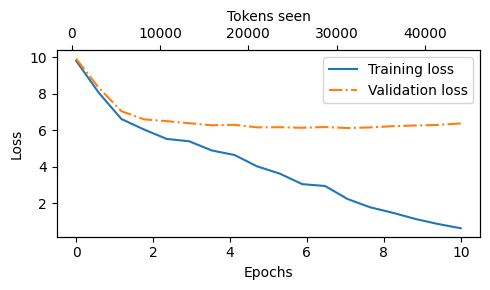

In [36]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5,3))
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax2 = ax1.twiny() # Creates a second x-axis that shares the same y-axis
    ax2.plot(tokens_seen, train_losses, alpha=0) # Invisible plot for aligning ticks
    ax2.set_xlabel("Tokens seen")
    fig.tight_layout()
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

这种差异以及验证损失远大于训练损失的事实表明，模型对训练数据进行了过度拟合。并且可以搜到 "quite insensible to the irony" 之类的文本，说明模型在记忆训练文本。    
这种记忆效应是预料之中的，因为我们使用的是一个非常小的训练数据集，并且对模型进行了多次迭代训练。

## 5.3 Decoding strategies to control randomness

In [37]:
model.to("cpu")
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

In [38]:
tokenizer = tiktoken.get_encoding("gpt2")
token_ids = generate_text_simple(
    model = model,
    idx = text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=25,
    context_size=GPT_CONFIG_124M["context_length"]
)
print("Output text: \n", token_ids_to_text(token_ids, tokenizer))

Output text: 
 Every effort moves you?"

"Yes--quite insensible to the irony. She wanted him vindicated--and by me!"




在每个生成步骤中选择的生成 token 对应于词汇表中所有 token 中最大的概率分数。这意味着即使我们在相同的起始上下文（"Every effort moves you"）上多次运行前面的 `generate_text_simple` 函数，LLM 也将始终生成相同的输出。

贪婪解码（Greedy decoding）：生成式人工智能中一种快速、确定且简单的推理策略，它在每一步都选择概率最高的下一个标记。

In [39]:
vocab = {
    "closer": 0,
    "every": 1,
    "effort": 2,
    "forwrd": 3,
     "inches": 4,
    "moves": 5,
    "pizza": 6,
    "toward": 7,
    "you": 8,
}
inverse_vocab = {v: k for k, v in vocab.items()}

In [40]:
inverse_vocab

{0: 'closer',
 1: 'every',
 2: 'effort',
 3: 'forwrd',
 4: 'inches',
 5: 'moves',
 6: 'pizza',
 7: 'toward',
 8: 'you'}

In [41]:
# 假设给 LLM 提供了起始上下文 "every effort moves you"，并生成了以下下一个 token 的 logits：
next_token_logits = torch.tensor(
    [4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]
)

In [42]:
# 以前在 generate_text_simple 中的做法，选择argmax输出的概率最高的token id
probas = torch.softmax(next_token_logits, dim=0)
next_token_id = torch.argmax(probas).item()
print(inverse_vocab[next_token_id])

forwrd


In [43]:
# 和直接输入logits给argmax的结果是相同的，因为logit越大=概率越高
# 都是logit=6.75最大的第4个词，对应forward
next_token_id = torch.argmax(next_token_logits).item()
print(inverse_vocab[next_token_id])

forwrd


使用 `multinomial` 代替 `argmax` 来获得概率分布的 next token

In [44]:
torch.manual_seed(123)
next_token_id = torch.multinomial(probas, num_samples = 1).item()
print(inverse_vocab[next_token_id])

forwrd


In [45]:
# bincount 计算1D列表中各个非负元素的出现频率
sample = torch.tensor([3, 3, 7, 7, 7, 1, 3, 3, 3, 7])
sampled_ids = torch.bincount(sample)
# 打印（下标，对应频率）
print([(i, ids.item()) for i,ids in enumerate(sampled_ids)])

[(0, 0), (1, 1), (2, 0), (3, 5), (4, 0), (5, 0), (6, 0), (7, 4)]


In [46]:
def print_sampled_tokens(probas):
    torch.manual_seed(123)
    sample = [torch.multinomial(probas, num_samples=1).item() for i in range(1_000)]
    # print(sample[:10])  # multinomial 根据概率分布抽取的token下标 [3, 3, 7, 7, 7, 7, 3, 3, 3, 7]
    sampled_ids = torch.bincount(torch.tensor(sample))
    for i, freq in enumerate(sampled_ids):
        print(f"{freq} x {inverse_vocab[i]}")

print_sampled_tokens(probas)

73 x closer
0 x every
0 x effort
582 x forwrd
2 x inches
0 x moves
0 x pizza
343 x toward


温度缩放本质上就是将 logits 除以一个大于 0 的数字，这个数字被称为温度（temperature）

大于 1 的温度会导致更均匀分布的 token 概率，而小于 1 的温度会导致更自信（更尖锐或更具峰值）的分布。

In [47]:
def softmax_with_temperature(logits, temperature):
    scaled_logits = logits / temperature
    return torch.softmax(scaled_logits, dim=0)

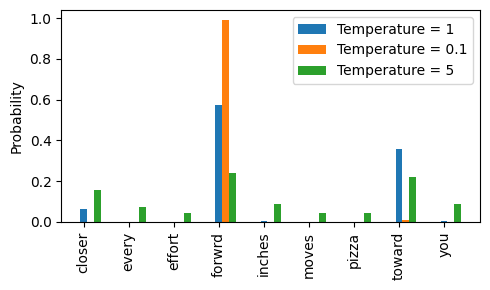

In [48]:
temperatures = [1, 0.1, 5]
scaled_probas = [softmax_with_temperature(next_token_logits, T) for T in temperatures]
x =  torch.arange(len(vocab))
bar_width = 0.15
fig, ax = plt.subplots(figsize=(5,3))
for i, T in enumerate(temperatures):
    rects = ax.bar(x + i * bar_width, scaled_probas[i],
                   bar_width, label=f'Temperature = {T}')
ax.set_ylabel("Probability")
ax.set_xticks(x)
ax.set_xticklabels(vocab.keys(), rotation=90)
ax.legend()
plt.tight_layout()
plt.show()

### Exercise 5.1

使用 `print_sampled_tokens` 函数打印图 5.14 中所示的、经温度缩放后的 Softmax 概率的采样频率。在每种情况下，单词“pizza”被采样的频率是多少？你能想到一种更快、更准确的方法来确定单词“pizza”被采样的频率吗？

In [49]:
temperatures = [1, 0.1, 5]
scaled_probas = [softmax_with_temperature(next_token_logits, T) for T in temperatures]
for i,sl in enumerate(scaled_probas):
    print(f"Temp = {temperatures[i]}")
    print_sampled_tokens(sl)
    print()

# 更准确的办法就是对温度缩放后的概率直接乘以次数，得到"pizza"的出现频率
freq = [int(x[6]*1000) for x in scaled_probas]
print(freq)

Temp = 1
73 x closer
0 x every
0 x effort
582 x forwrd
2 x inches
0 x moves
0 x pizza
343 x toward

Temp = 0.1
0 x closer
0 x every
0 x effort
985 x forwrd
0 x inches
0 x moves
0 x pizza
15 x toward

Temp = 5
165 x closer
75 x every
42 x effort
239 x forwrd
71 x inches
46 x moves
32 x pizza
227 x toward
103 x you

[0, 0, 42]


In [50]:
top_k = 3
top_logits, top_pos = torch.topk(next_token_logits, top_k)
print("Top logits:", top_logits)    # 缩减后的概率分布
print("Top positions:", top_pos)    # 概率分布对应原下标

Top logits: tensor([6.7500, 6.2800, 4.5100])
Top positions: tensor([3, 7, 0])


In [51]:
new_logits = torch.where(
    condition = next_token_logits < top_logits[-1], # 找到低于top3最低概率的logit
    input = torch.tensor(float('-inf')),            # 替换为-inf
    other = next_token_logits                       # 保留top3概率
)
print(new_logits)

tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])


In [52]:
topk_probas = torch.softmax(new_logits, dim=0)
print(topk_probas)

tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])


现在，我们可以应用温度缩放和多项式采样函数，从这三个非零概率分数中选择下一个token，以生成下一个token。

In [53]:
idx = torch.tensor([1,2,3])
idx_next = torch.tensor([4])

idx=torch.cat((idx, idx_next))
print(idx)

tensor([1, 2, 3, 4])


In [54]:
def generate(model, idx, max_new_tokens, context_size, temperature=0.0, top_k=None, eos_id=None):
    # idx [batch,context_size] [1, 4]
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        # print(logits.shape) # [1, 4, 50257]
        logits = logits[:, -1, :] # 只取每批生成的token的dims
        if top_k is not None:   # 过滤 top k个样本
            # [batch][1][top_k] 
            top_logits, top_pos = torch.topk(logits, top_k)
            min_val = top_logits[:,-1]
            logits = torch.where(
                condition = logits< min_val,
                input = torch.tensor(float("-inf")).to(logits.device),
                other = logits
            )
        if temperature > 0.0:   # 温度缩放
            logits = logits/ temperature
            probas = torch.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probas, num_samples=1)
        else:   # 温度缩放禁用时，执行 greedy decoding
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)
        if idx_next==eos_id:    # 出现终止符则提前结束
            break
        idx = torch.cat((idx, idx_next), dim=1)
    return idx

In [55]:
torch.manual_seed(123)
token_ids = generate(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=15,
    context_size=GPT_CONFIG_124M["context_length"],
    top_k=25,
    temperature=1.4
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you?"
His up surprise. And whenever his glory, when by his head


### Exercise 5.2    
尝试不同的温度（temperature）和 top-k 设置。根据你的观察，你能想到哪些场景需要较低的温度和 top-k 设置吗？同样，你能想到哪些场景更倾向于使用较高的温度和 top-k 设置吗？（建议在读完本章末尾、加载 OpenAI 的预训练权重后，重新进行此练习。）

In [56]:
token_ids = generate(
    model, 
    idx=text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=20,
    context_size=GPT_CONFIG_124M["context_length"],
    top_k=10,
    temperature=1.4
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you?"

"Yes--quite insensible to the deprecating laugh word so with a no


In [57]:
token_ids = generate(
    model, 
    idx=text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=20,
    context_size=GPT_CONFIG_124M["context_length"],
    top_k=10,
    temperature=0.8
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you?"
"I he was too? I felt nervous and uncertain. Stroud so when I had


###  Exercise 5.3   
What are the different combinations of settings for the generate function to force
deterministic behavior, that is, disabling the random sampling such that it always pro-
duces the same outputs similar to the generate_simple function?   
为了强制实现确定性行为（即禁用随机采样，使其始终产生与 `generate_simple` 函数类似的相同输出），`generate` 函数有哪些不同的设置组合？

In [58]:
# 1. topk=1
token_ids = generate(
    model, 
    idx=text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=20,
    context_size=GPT_CONFIG_124M["context_length"],
    top_k=1,
    temperature=0.5
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you?"

"Yes--quite insensible to the irony. She wanted him vindicated--and


In [59]:
# 1. temp = 0.0
token_ids = generate(
    model, 
    idx=text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=20,
    context_size=GPT_CONFIG_124M["context_length"],
    top_k=15,
    temperature=0.0
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you?"

"Yes--quite insensible to the irony. She wanted him vindicated--and


## 5.4 Loading and saving model weights in PyTorch

In [60]:
torch.save(model.state_dict(), "model.pth")

In [61]:
model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(torch.load("model.pth", map_location=device))
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

为了以后继续训练，还需要存储optimizer的参数

In [62]:
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    },
    "model_and_optimizer.pth"
)

然后我们可以通过先使用 `torch.load` 加载保存的数据，再使用 `load_state_dict` 方法来恢复模型和优化器的状态。

In [85]:
checkpoint = torch.load("model_and_optimizer.pth", map_location=device)
model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(checkpoint["model_state_dict"])
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=0.1)
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
model.train()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

### Exercise 5.4   
保存权重后，在一个新的 Python 会话或 Jupyter notebook 文件中加载模型和优化器，并使用 train_model_simple 函数继续对其进行一个 epoch 的预训练

错误（`Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu!`）在 PyTorch 中非常常见。这通常是因为模型的参数、优化器的内部状态（如动量缓冲区）或输入数据分布在不同的设备（例如一部分在 GPU，一部分在 CPU）上导致的。

针对你的代码，最容易出现这个问题的地方在于：**加载优化器状态时，优化器内部的张量可能仍保留在 CPU 上，而模型已经移至 GPU**。

---

### 解决方案

请参考以下修改后的代码。主要调整了以下几个关键点：
1. **提前将模型移动到设备上**。
2. **手动将优化器的状态转移到目标设备**。

```python
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. 实例化模型并直接移动到设备
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
# 2. 加载模型状态字典
#....
# 3. 初始化优化器并加载状态字典
#...
# 4. 关键修复：将优化器的所有内部状态参数（如动量）显式移动到与模型相同的设备
for state in optimizer.state.values():
    for k, v in state.items():
        if isinstance(v, torch.Tensor):
            state[k] = v.to(device)

model.train()

# ...
# 5. 运行训练
# ...
```

### 为什么会出现这个问题？

1. **优化器状态 (Optimizer State)**：即使使用 `map_location=device` 将模型参数加载到了正确的设备，`optimizer.load_state_dict(...)` 恢复时有时会将动量缓存（momentum buffers）保留在原先被保存时的设备（通常是 CPU）。
2. **训练函数内部**：如果 `train_model_simple` 内部在读取 `train_loader` 时，传递给模型的 `input_ids` 没有被 `.to(device)` 处理，数据就会停留在 CPU，而模型在 GPU 上。你可以检查 `train_model_simple` 内部是否有类似 `inputs, targets = batch` 且没有 `inputs.to(device)` 的逻辑。

In [88]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
checkpoint = torch.load("model_and_optimizer.pth", map_location=device)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
model.load_state_dict(checkpoint["model_state_dict"])
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=0.1)
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

# 关键修复：将优化器的所有内部状态参数（如动量）显式移动到与模型相同的设备
for state in optimizer.state.values():
    for k, v in state.items():
        if isinstance(v, torch.Tensor):
            state[k] = v.to(device)

model.train()

torch.manual_seed(123)
num_epochs = 1
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context="Every effort moves you", tokenizer=tokenizer
)

Ep 1 (Stpen 000000): Train loss 0.481, Val loss 6.413
Ep 1 (Stpen 000005): Train loss 0.329, Val loss 6.442
Every effort moves you?"                               He placed them at my elbow and continued to wander up and down the room, and his


## 5.5 Loading pretrained weights from OpenAI

In [64]:
import urllib.request
url = (
    "https://raw.githubusercontent.com/rasbt/"
    "LLMs-from-scratch/main/ch05/"
    "01_main-chapter-code/gpt_download.py"
)
filename = url.split('/')[-1]
urllib.request.urlretrieve(url, filename)

('gpt_download.py', <http.client.HTTPMessage at 0x792e5826c6e0>)

In [65]:
# 架构设置 settings, 模型权重 params
from gpt_download import download_and_load_gpt2
settings, params = download_and_load_gpt2(
    model_size="124M", models_dir="gpt2"
)


checkpoint: 100%|██████████| 77.0/77.0 [00:00<00:00, 60.6kiB/s]
encoder.json: 100%|██████████| 1.04M/1.04M [00:00<00:00, 2.79MiB/s]
hparams.json: 100%|██████████| 90.0/90.0 [00:00<00:00, 143kiB/s]
model.ckpt.data-00000-of-00001: 100%|██████████| 498M/498M [00:32<00:00, 15.4MiB/s] 
model.ckpt.index: 100%|██████████| 5.21k/5.21k [00:00<00:00, 6.58MiB/s]
model.ckpt.meta: 100%|██████████| 471k/471k [00:00<00:00, 1.66MiB/s]
vocab.bpe: 100%|██████████| 456k/456k [00:00<00:00, 1.33MiB/s]


In [66]:
print("Setting:", settings)
print("Parameter dictionary keys:", params.keys())

Setting: {'n_vocab': 50257, 'n_ctx': 1024, 'n_embd': 768, 'n_head': 12, 'n_layer': 12}
Parameter dictionary keys: dict_keys(['blocks', 'b', 'g', 'wpe', 'wte'])


In [67]:
print(params["wte"])
print("Token embedding weight tensor dimensions:", params["wte"].shape)

[[-0.11010301 -0.03926672  0.03310751 ... -0.1363697   0.01506208
   0.04531523]
 [ 0.04034033 -0.04861503  0.04624869 ...  0.08605453  0.00253983
   0.04318958]
 [-0.12746179  0.04793796  0.18410145 ...  0.08991534 -0.12972379
  -0.08785918]
 ...
 [-0.04453601 -0.05483596  0.01225674 ...  0.10435229  0.09783269
  -0.06952604]
 [ 0.1860082   0.01665728  0.04611587 ... -0.09625227  0.07847701
  -0.02245961]
 [ 0.05135201 -0.02768905  0.0499369  ...  0.00704835  0.15519823
   0.12067825]]
Token embedding weight tensor dimensions: (50257, 768)


In [68]:
model_configs = {
    "gpt2-small(124M)":{"emb_dim":768, "n_layers":12, "n_heads":12},
    "gpt2-medium(355M)":{"emb_dim":1024, "n_layers":24, "n_heads":16},
    "gpt2-large(774M)":{"emb_dim":1280, "n_layers":36, "n_heads":20},
    "gpt2-xl(1558M)":{"emb_dim":1600, "n_layers":48, "n_heads":25},
}

这段代码使用 `.copy()` 再 `.update()`，是为了在保留原始基础配置（GPT_CONFIG_124M）的基础上，安全地创建一个特定模型的配置副本，同时避免对原始配置产生副作用。

In [69]:
model_name = "gpt2-small(124M)"
NEW_CONFIG = GPT_CONFIG_124M.copy()
NEW_CONFIG.update(model_configs[model_name])

In [70]:
NEW_CONFIG.update({"context_length": 1024})

此外，OpenAI 在多头注意力模块的线性层中使用偏差向量来实现查询、关键字和值矩阵计算。偏差向量在 LLM 中已不常用，因为它们无法提高建模性能，因此也就没有必要了。不过，由于我们使用的是预训练权重，因此需要匹配这些设置以保持一致性，并启用这些偏差向量：

In [71]:
NEW_CONFIG.update({"qkv_bias": True})

In [72]:
gpt = GPTModel(NEW_CONFIG)
gpt.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

In [73]:
def assign(left, right):
    if left.shape!= right.shape:
        raise ValueError(f"Shape mismatch. Left: {left.shape}, Right: {right.shape}")
    return torch.nn.Parameter(torch.tensor(right))

In [ ]:
import numpy as np

# 将模型的位置和标记嵌入权重设置为 params 中指定的权重
def load_weights_into_gpt(gpt, params):
    gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params['wpe'])
    gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params['wte'])
    
    for b in range(len(params["blocks"])):  # 遍历  transformer block 
        # 使用 np.split 函数将注意力和偏置权重平分为 query, key, value 三个部分
        q_w, k_w, v_w = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["w"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.weight = assign(gpt.trf_blocks[b].att.W_query.weight, q_w.T)
        gpt.trf_blocks[b].att.W_key.weight = assign(gpt.trf_blocks[b].att.W_key.weight, k_w.T)
        gpt.trf_blocks[b].att.W_value.weight = assign(gpt.trf_blocks[b].att.W_value.weight, v_w.T)

        q_b, k_b, v_b = np.split((params["blocks"][b]["attn"]["c_attn"])["b"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.bias = assign(gpt.trf_blocks[b].att.W_query.bias, q_b)
        gpt.trf_blocks[b].att.W_key.bias = assign(gpt.trf_blocks[b].att.W_key.bias, k_b)
        gpt.trf_blocks[b].att.W_value.bias = assign(gpt.trf_blocks[b].att.W_value.bias, v_b)

        gpt.trf_blocks[b].att.out_proj.weight = assign(
            gpt.trf_blocks[b].att.out_proj.weight,
            params["blocks"][b]["attn"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].att.out_proj.bias = assign(
            gpt.trf_blocks[b].att.out_proj.bias,
            params["blocks"][b]["attn"]["c_proj"]["b"].T)

        gpt.trf_blocks[b].ff.layers[0].weight = assign(
        gpt.trf_blocks[b].ff.layers[0].weight,
        params["blocks"][b]["mlp"]["c_fc"]["w"].T)
        gpt.trf_blocks[b].ff.layers[0].bias = assign(
        gpt.trf_blocks[b].ff.layers[0].bias,
        params["blocks"][b]["mlp"]["c_fc"]["b"])
        gpt.trf_blocks[b].ff.layers[2].weight = assign(
        gpt.trf_blocks[b].ff.layers[2].weight,
        params["blocks"][b]["mlp"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].ff.layers[2].bias = assign(
        gpt.trf_blocks[b].ff.layers[2].bias,
        params["blocks"][b]["mlp"]["c_proj"]["b"])
        gpt.trf_blocks[b].norm1.scale = assign(
        gpt.trf_blocks[b].norm1.scale,
        params["blocks"][b]["ln_1"]["g"])
        gpt.trf_blocks[b].norm1.shift = assign(
        gpt.trf_blocks[b].norm1.shift,
        params["blocks"][b]["ln_1"]["b"])
        gpt.trf_blocks[b].norm2.scale = assign(
        gpt.trf_blocks[b].norm2.scale,
        params["blocks"][b]["ln_2"]["g"])
        gpt.trf_blocks[b].norm2.shift = assign(
        gpt.trf_blocks[b].norm2.shift,
        params["blocks"][b]["ln_2"]["b"])

    # OpenAI 的原始 GPT-2 模型重用了输出层中的标记嵌入权重，以减少参数总数，这一概念被称为权重绑定。
    gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"])
    gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"])
    gpt.out_head.weight = assign(gpt.out_head.weight, params["wte"])

In [82]:
load_weights_into_gpt(gpt, params)
gpt.to(device)

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

In [83]:
torch.manual_seed(123)
token_ids = generate(
    model = gpt,
    idx = text_to_token_ids("Every effort moves you", tokenizer).to(device),
    max_new_tokens = 25,
    context_size = NEW_CONFIG["context_length"],
    top_k = 50,
    temperature=1.5
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you as far as the hand can go until the end of your turn unless something happens

This would remove you from a battle


### 练习 5.5     
计算使用了 OpenAI 预训练权重的 GPTModel 在《The Verdict》数据集上的训练集和验证集损失。

In [84]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
gpt.to(device)

with torch.no_grad(): # 尚未开始训练，为了提高效率，禁用梯度追踪
    train_loss = calc_loss_loader(train_loader, gpt, device)
    val_loss = calc_loss_loader(val_loader, gpt, device)

print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 3.754763126373291
Validation loss: 3.5596330165863037


### 练习 5.6     
尝试使用不同大小的 GPT-2 模型（例如最大的 15.58 亿参数模型），并将生成的文本与 1.24 亿参数模型进行比较。

In [91]:

settings, params = download_and_load_gpt2(
    model_size="1558M", models_dir="gpt2"
)

checkpoint: 100%|██████████| 77.0/77.0 [00:00<00:00, 218kiB/s]
encoder.json: 100%|██████████| 1.04M/1.04M [00:00<00:00, 3.21MiB/s]
hparams.json: 100%|██████████| 91.0/91.0 [00:00<00:00, 183kiB/s]
model.ckpt.data-00000-of-00001:  50%|████▉     | 3.09G/6.23G [08:01<08:09, 6.42MiB/s] 


Primary URL (https://openaipublic.blob.core.windows.net/gpt-2/models/1558M/model.ckpt.data-00000-of-00001) failed. Attempting backup URL: https://f001.backblazeb2.com/file/LLMs-from-scratch/gpt2/1558M/model.ckpt.data-00000-of-00001


model.ckpt.data-00000-of-00001: 100%|██████████| 6.23G/6.23G [15:16<00:00, 6.80MiB/s] 
model.ckpt.index: 100%|██████████| 20.7k/20.7k [00:00<00:00, 24.7MiB/s]
model.ckpt.meta: 100%|██████████| 1.84M/1.84M [00:00<00:00, 3.54MiB/s]
vocab.bpe: 100%|██████████| 456k/456k [00:00<00:00, 1.65MiB/s]


: 

: 

: 

In [ ]:
print("Setting:", settings)
print("Parameter dictionary keys:", params.keys())

In [89]:
model_configs

{'gpt2-small(124M)': {'emb_dim': 768, 'n_layers': 12, 'n_heads': 12},
 'gpt2-medium(355M)': {'emb_dim': 1024, 'n_layers': 24, 'n_heads': 16},
 'gpt2-large(774M)': {'emb_dim': 1280, 'n_layers': 36, 'n_heads': 20},
 'gpt2-xl(1558M)': {'emb_dim': 1600, 'n_layers': 48, 'n_heads': 25}}

In [ ]:
xl_model_name = "gpt2-xl(1558M)"
XL_CONFIG = GPT_CONFIG_1558M.copy()
XL_CONFIG.update(model_configs[xl_model_name])
NEW_CONFIG.update({"context_length": 1024})
NEW_CONFIG.update({"qkv_bias": True})
gpt = GPTModel(NEW_CONFIG)
gpt.eval()